## Predicting the Sale Price of Bulldozers (Time Series Data) using Machine Learning

Download the dataset from here [Bulldozer Dataset](https://github.com/mrdbourke/zero-to-mastery-ml/raw/master/data/bluebook-for-bulldozers.zip)

There are 3 main datasets

- Train.csv
- Valid.csv
- Test.csv

The evauation metiic is RMSLE (Root Mean Squared Log Error)


In [283]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

In [284]:
# import training and validation datasets

df = pd.read_csv("bluebook-for-bulldozers/TrainAndValid.csv", low_memory=False)

In [285]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [286]:
df.isnull().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

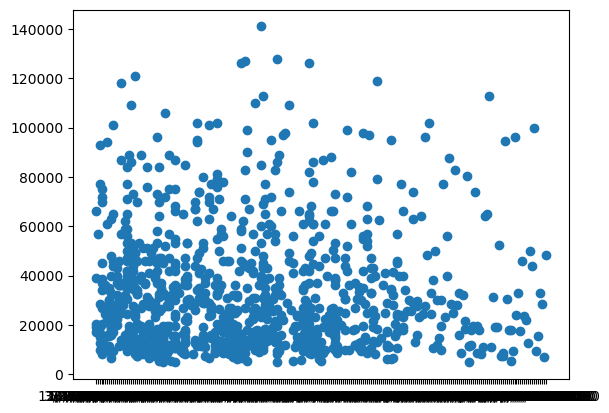

In [287]:
plt.scatter(df["saledate"][:1000], df["SalePrice"][:1000])

plt.show()

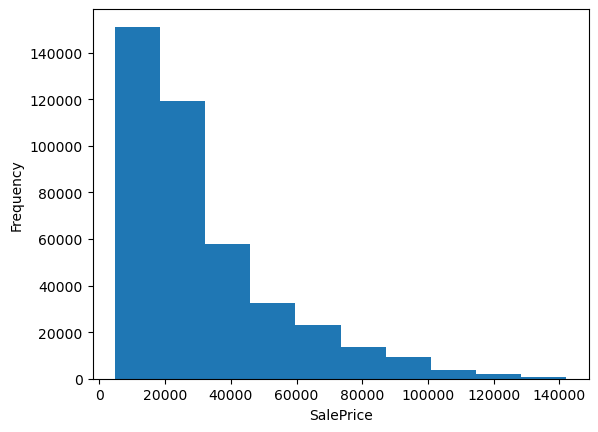

In [288]:
df.SalePrice.plot.hist()
plt.xlabel("SalePrice")
plt.show()

### Parsing Date

When we work with time series data, we want to enrich the time & date component as much as possible.

We can do that by telling pandas which of our columns has dates in it using the `parse_dates` parameter


In [289]:
df = pd.read_csv(
    "bluebook-for-bulldozers/TrainAndValid.csv",
    low_memory=False,
    parse_dates=["saledate"],
)

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   412698 non-null  int64         
 1   SalePrice                 412698 non-null  float64       
 2   MachineID                 412698 non-null  int64         
 3   ModelID                   412698 non-null  int64         
 4   datasource                412698 non-null  int64         
 5   auctioneerID              392562 non-null  float64       
 6   YearMade                  412698 non-null  int64         
 7   MachineHoursCurrentMeter  147504 non-null  float64       
 8   UsageBand                 73670 non-null   object        
 9   saledate                  412698 non-null  datetime64[ns]
 10  fiModelDesc               412698 non-null  object        
 11  fiBaseModel               412698 non-null  object        
 12  fi

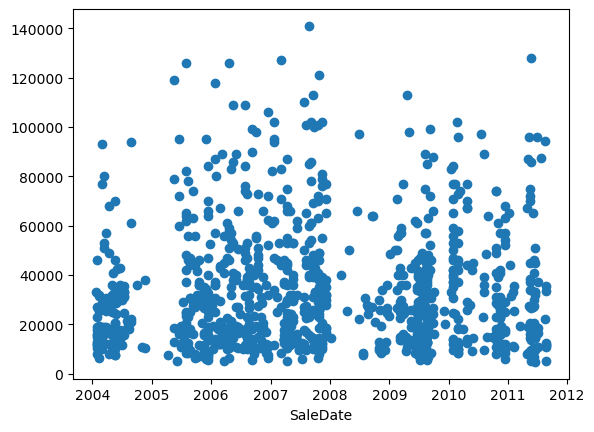

In [291]:
plt.scatter(df["saledate"][:1000], df["SalePrice"][:1000])
plt.xlabel("SaleDate")
plt.show()

In [292]:
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


In [293]:
# Sort the dataframe by saledate
df.sort_values(by=["saledate"], inplace=True, ascending=True)

## Feature Engineering


In [294]:
# make a copy
df_tmp = df.copy()

In [295]:
df_tmp["saleYear"] = df_tmp.saledate.dt.year
df_tmp["saleMonth"] = df_tmp.saledate.dt.month
df_tmp["saleDay"] = df_tmp.saledate.dt.day
df_tmp["saleDayOfWeek"] = df_tmp.saledate.dt.dayofweek
df_tmp["saleDayOfYear"] = df_tmp.saledate.dt.dayofyear

In [296]:
# now we can remove saledate
df_tmp.drop("saledate", axis=1, inplace=True)

In [297]:
# change the objects datatype to category datatype

for label, column in df_tmp.items():
    # label is column name, column are column items list
    if pd.api.types.is_object_dtype(column):
        df_tmp[label] = column.astype("category").cat.as_ordered()

In [298]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

In [299]:
df_tmp.state.cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='object')

In [300]:
df_tmp.state.cat.codes

205615    43
274835     8
141296     8
212552     8
62755      8
          ..
410879     4
412476     4
411927     4
407124     4
409203     4
Length: 412698, dtype: int8

## Check for missing data


In [301]:
# how many percent of the data is missing
df_tmp.isnull().sum() / len(df_tmp)

SalesID                     0.000000
SalePrice                   0.000000
MachineID                   0.000000
ModelID                     0.000000
datasource                  0.000000
auctioneerID                0.048791
YearMade                    0.000000
MachineHoursCurrentMeter    0.642586
UsageBand                   0.821492
fiModelDesc                 0.000000
fiBaseModel                 0.000000
fiSecondaryDesc             0.340993
fiModelSeries               0.857845
fiModelDescriptor           0.818715
ProductSize                 0.524851
fiProductClassDesc          0.000000
state                       0.000000
ProductGroup                0.000000
ProductGroupDesc            0.000000
Drive_System                0.740520
Enclosure                   0.000809
Forks                       0.520921
Pad_Type                    0.803498
Ride_Control                0.629928
Stick                       0.803498
Transmission                0.544444
Turbocharged                0.803498
B

In [302]:
# filling numeric missing values first
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # add a binary column which tells us if the data was missing or not
            df_tmp[label + "_is_missing"] = pd.isnull(content)
            # fill missing numeric values with median
            df_tmp[label] = content.fillna(content.median())

In [303]:
df_tmp.auctioneerID_is_missing.value_counts()  # True will tell us how many missing values were there in auctioneerID column

auctioneerID_is_missing
False    392562
True      20136
Name: count, dtype: int64

In [304]:
df_tmp.isnull().sum()

SalesID                                     0
SalePrice                                   0
MachineID                                   0
ModelID                                     0
datasource                                  0
auctioneerID                                0
YearMade                                    0
MachineHoursCurrentMeter                    0
UsageBand                              339028
fiModelDesc                                 0
fiBaseModel                                 0
fiSecondaryDesc                        140727
fiModelSeries                          354031
fiModelDescriptor                      337882
ProductSize                            216605
fiProductClassDesc                          0
state                                       0
ProductGroup                                0
ProductGroupDesc                            0
Drive_System                           305611
Enclosure                                 334
Forks                             

In [305]:
# filling categorical missing values

for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        df_tmp[label + "_is_missing"] = pd.isnull(content)
        # by default -1 is assigned to missing values in categorical columns
        # +1 because -1 is for missing values
        # now 0 will be there as categorical value where value is missing
        df_tmp[label] = pd.Categorical(content).codes + 1

In [306]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
...,...,...,...,...,...
Backhoe_Mounting_is_missing,False,True,False,True,False
Blade_Type_is_missing,False,True,False,True,False
Travel_Controls_is_missing,False,True,False,True,False
Differential_Type_is_missing,True,False,True,False,True


In [307]:
# Save preprocessed data

df_tmp.to_csv("bluebook-for-bulldozers/TrainAndValid_preprocessed.csv", index=False)

## Modeling


In [308]:
%%time
## Modeling, Model driven EDA, Feature importance

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_jobs=-1, random_state=42)

model.fit(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

CPU times: total: 40min 33s
Wall time: 5min 6s


RandomForestRegressor(n_jobs=-1, random_state=42)

In [309]:
model.score(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

0.9875468079970562

## Split data into training and validation


In [310]:
df_val = df_tmp[df_tmp.saleYear == 2012]
df_train = df_tmp[df_tmp.saleYear != 2012]

df_val.shape, df_train.shape

((11573, 103), (401125, 103))

In [311]:
# split data into X and y

X_train, y_train = df_train.drop("SalePrice", axis=1), df_train["SalePrice"]
X_valid, y_valid = df_val.drop("SalePrice", axis=1), df_val["SalePrice"]

In [312]:
from sklearn.metrics import (
    root_mean_squared_log_error as rmsle,
    mean_absolute_error as mae,
    r2_score,
)

In [313]:
def show_scores(model):
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_valid)

    scores = {
        "Train RMSLE": rmsle(y_train, train_preds),
        "Validation RMSLE": rmsle(y_valid, val_preds),
        "Train MAE": mae(y_train, train_preds),
        "Validation MAE": mae(y_valid, val_preds),
        "Training R2": r2_score(y_train, train_preds),
        "Validation R2": r2_score(y_valid, val_preds),
    }
    return scores

In [314]:
show_scores(model)

{'Train RMSLE': 0.0841144059088283,
 'Validation RMSLE': 0.08746318355899653,
 'Train MAE': 1576.4843819607352,
 'Validation MAE': 1869.2186318154324,
 'Training R2': 0.987563251253579,
 'Validation R2': 0.9868076830397394}

## Hyperparameter tuning


In [315]:
model = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    max_samples=10000,
)

In [316]:
%%time

model.fit(X_train, y_train)

CPU times: total: 1min 17s
Wall time: 8.82 s


RandomForestRegressor(max_samples=10000, n_jobs=-1, random_state=42)

In [317]:
show_scores(model)

{'Train RMSLE': 0.257745378256977,
 'Validation RMSLE': 0.29362638671089003,
 'Train MAE': 5561.2988092240585,
 'Validation MAE': 7177.26365505919,
 'Training R2': 0.8606658995199189,
 'Validation R2': 0.8320374995090507}

In [318]:
from sklearn.model_selection import RandomizedSearchCV

In [319]:
%%time

rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2),
    "max_features": [0.5, 1, "sqrt", "auto"],
    "max_samples": [10000],
}

rs_model = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=rf_grid,
    n_iter=20,
    cv=5,
    verbose=True,
)

rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: total: 7min 37s
Wall time: 2min 49s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt',
                                                         'auto'],
                                        'max_samples': [10000],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90])},
                   verbose=True)

In [320]:
rs_model.best_params_

{'n_estimators': 20,
 'min_samples_split': 14,
 'min_samples_leaf': 13,
 'max_samples': 10000,
 'max_features': 0.5,
 'max_depth': 10}

In [321]:
ideal_model = RandomForestRegressor(
    n_estimators=70,
    min_samples_leaf=1,
    min_samples_split=10,
    max_features=0.5,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    max_samples=10000,
)

ideal_model.fit(X_train, y_train)

RandomForestRegressor(max_features=0.5, max_samples=10000, min_samples_split=10,
                      n_estimators=70, n_jobs=-1, random_state=42)

In [322]:
show_scores(ideal_model)

{'Train RMSLE': 0.2695927025327064,
 'Validation RMSLE': 0.29963930574974657,
 'Train MAE': 5886.08378547758,
 'Validation MAE': 7276.24909296157,
 'Training R2': 0.8465179828451148,
 'Validation R2': 0.8310731145712691}

## Predictions on the Test Dataset


In [323]:
df_test = pd.read_csv(
    "bluebook-for-bulldozers/Test.csv", low_memory=False, parse_dates=["saledate"]
)

df_test["auctioneerID"][0] = np.nan

In [324]:
def preprocess_data(df):
    df.sort_values(by=["saledate"], inplace=True, ascending=True)

    df["saleYear"] = df.saledate.dt.year
    df["saleMonth"] = df.saledate.dt.month
    df["saleDay"] = df.saledate.dt.day
    df["saleDayOfWeek"] = df.saledate.dt.dayofweek
    df["saleDayOfYear"] = df.saledate.dt.dayofyear

    df.drop("saledate", axis=1, inplace=True)

    for label, column in df.items():
        if pd.api.types.is_object_dtype(column):
            df[label] = column.astype("category").cat.as_ordered()

    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                # add a binary column which tells us if the data was missing or not
                df[label + "_is_missing"] = pd.isnull(content)
                # fill missing numeric values with median
                df[label] = content.fillna(content.median())

    for label, content in df.items():
        if not pd.api.types.is_numeric_dtype(content):
            df[label + "_is_missing"] = pd.isnull(content)
            # by default -1 is assigned to missing values in categorical columns
            # +1 because -1 is for missing values
            # now 0 will be there as categorical value where value is missing
            df[label] = pd.Categorical(content).codes + 1

    return df

In [325]:
df_test = preprocess_data(df_test)

In [326]:
test_preds = ideal_model.predict(df_test)

In [327]:
test_preds

array([11215.27636054, 18030.38323284, 20932.58155535, ...,
       44295.6207483 , 47617.17120181, 37367.85289116])

In [328]:
df_preds = pd.DataFrame()

df_preds["SalesID"] = df_test["SalesID"]
df_preds["SalePrice"] = test_preds

In [329]:
df_preds

,SalesID,SalePrice
1408,4317459,11215.276361
1023,4249784,18030.383233
1728,4392603,20932.581555
1167,4274831,33520.919785
1594,4362801,18413.142574
...,...,...
9941,6620191,9961.647727
9936,6620142,12965.289116
11620,6635116,44295.620748
9995,6621460,47617.171202


## Feature Importance


In [330]:
ideal_model.feature_importances_

array([3.10672344e-02, 2.82225084e-02, 4.54830928e-02, 2.23449331e-03,
       5.02806579e-03, 1.99355599e-01, 3.99495144e-03, 1.60482190e-03,
       4.26973972e-02, 3.49972692e-02, 5.76124573e-02, 4.42149396e-03,
       1.96297281e-02, 1.51247136e-01, 4.27900980e-02, 8.23631021e-03,
       5.24857788e-03, 4.72301737e-03, 2.57972444e-03, 6.17580133e-02,
       1.69351325e-03, 7.70825916e-05, 1.62528756e-03, 6.22348926e-04,
       1.36562519e-03, 4.30930700e-05, 1.41225997e-03, 9.32735311e-03,
       4.05445094e-03, 1.63591736e-03, 4.10452075e-03, 2.64313076e-03,
       5.01301697e-03, 8.29672662e-04, 5.00697103e-04, 1.23710726e-02,
       1.35485059e-03, 1.60317626e-02, 1.62048002e-03, 3.77253624e-03,
       8.51767333e-04, 1.36208639e-03, 2.72395700e-03, 8.49031061e-04,
       7.70515822e-04, 7.75768220e-04, 4.77927845e-04, 3.28721085e-03,
       1.12317637e-03, 3.10704062e-04, 4.95728137e-04, 5.79232486e-02,
       4.65608534e-03, 8.88473878e-03, 4.53413162e-03, 1.13409306e-02,
      

In [331]:
def plot_features(columns, importances, n=20):
    df = (
        pd.DataFrame({"features": columns, "feature_importances": importances})
        .sort_values("feature_importances", ascending=False)
        .reset_index(drop=True)
    )

    # plot the top n features
    fig, ax = plt.subplots()

    ax.barh(df["features"][:n], df["feature_importances"][:n])

    ax.set_xlabel("Feature Importance")
    ax.set_title("Feature Importances (Top 20)")
    ax.invert_yaxis()
    plt.show()

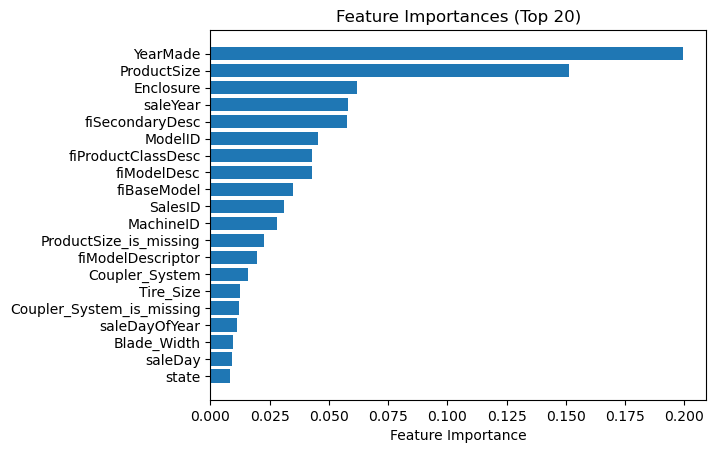

In [332]:
plot_features(X_train.columns, ideal_model.feature_importances_)